# Differentiable Particle Filtering with Non-Gaussian Emissions

Differentiable particle filters offer a methodology for non-Gaussian emissions, even with multi-modal belief distributions. We include two examples, using Poisson emissions and von-Mises emissions.

In [1]:
import jax.numpy as jnp
import jax.random as jr
from cd_dynamax import ContDiscreteNonlinearSSM, ContDiscreteNonlinearGaussianSSM
from cd_dynamax.src.continuous_discrete_nonlinear_ssm.builders import PoissonEmission
import matplotlib.pyplot as plt
import equinox as eqx
import matplotlib as mpl
from jax import value_and_grad, vmap

## Differentiable particle filtering with Poisson emissions

To illustrate the usefulness of the differentiable particle filter, we will perform filtering on a state spoce model with non-Gaussian observations. In particular, we simulate a 1D continuous-time SDE (Ornstein-Uhlenbeck process), then generate Poisson counts via an exponential link function. 


### Model and Simulated Data

Latent dynamics (1D OU SDE):

$$ d x(t) = \kappa (\mu - x(t)) \, dt + \sigma \, dW(t) $$

Observation model (binned Poisson process counts):

$$ y_k \mid x_k \sim \text{Poisson}(\Delta t \cdot \exp(x_k + b)) $$

We’ll sample the latent path and Poisson emissions directly from the CD-NLSSM (non-Gaussian emissions) using its path sampler.



In [2]:
# Time grid
dt = 0.1
T = 1_000
t_emissions = (jnp.arange(T) * dt).reshape(-1, 1)

# True latent dynamics parameters
true_kappa = 0.8
true_mu = 0.0
true_sigma = 0.4

def drift_ou(x, kappa=true_kappa, mu=true_mu):
    # x has shape (1,)
    return kappa * (mu - x)

# Initial state distribution
initial_sd = 0.5

cdnlssm = ContDiscreteNonlinearSSM(state_dim=1, emission_dim=1)
poisson_emission = PoissonEmission(dt=float(dt), bias=jnp.log(50.0))

sim_params = cdnlssm.build_params(
    drift=lambda x: drift_ou(x, kappa=true_kappa, mu=true_mu),
    initial_mean=jnp.array([0.0]),
    initial_cov=(initial_sd**2) * jnp.eye(1),
    diffusion_coeff=true_sigma * jnp.eye(1),
    emission_distribution=poisson_emission,
)

states, emissions = cdnlssm.sample(
    params=sim_params,
    key=jr.PRNGKey(0),
    num_timesteps=T,
    t_emissions=t_emissions,
    transition_type="path",
)

true_bias = poisson_emission.bias
rates = dt * jnp.exp(states[:, 0] + true_bias)



Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.


In [3]:
# Make emissions explicitly (T, 1) for filtering/plotting
emissions = emissions.reshape(-1, 1)

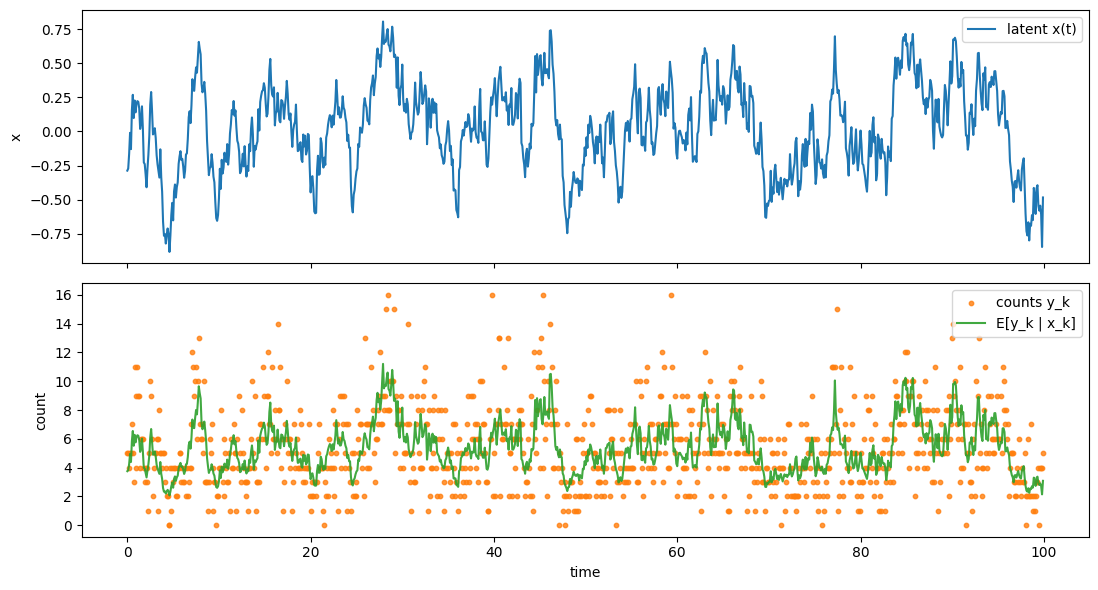

In [4]:
# Plot latent state + Poisson counts
t = t_emissions.squeeze()

fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axs[0].plot(t, states[:, 0], color="C0", label="latent x(t)")
axs[0].set_ylabel("x")
axs[0].legend(loc="upper right")

axs[1].scatter(t, emissions[:, 0], s=10, color="C1", alpha=0.8, label="counts y_k")
axs[1].plot(t, rates, color="C2", alpha=0.9, label="E[y_k | x_k]")
axs[1].set_ylabel("count")
axs[1].set_xlabel("time")
axs[1].legend(loc="upper right")

plt.tight_layout()



### Filtering Using a Differentiable Particle Filter

In [5]:
filtered = cdnlssm.filter(
    params=sim_params,
    emissions=emissions,
    t_emissions=t_emissions,
    key=jr.PRNGKey(1),
    N_particles=1_000,
    warn=False,
)

print("DPF marginal log-likelihood:", float(filtered.marginal_loglik))

DPF marginal log-likelihood: -2328.6708984375


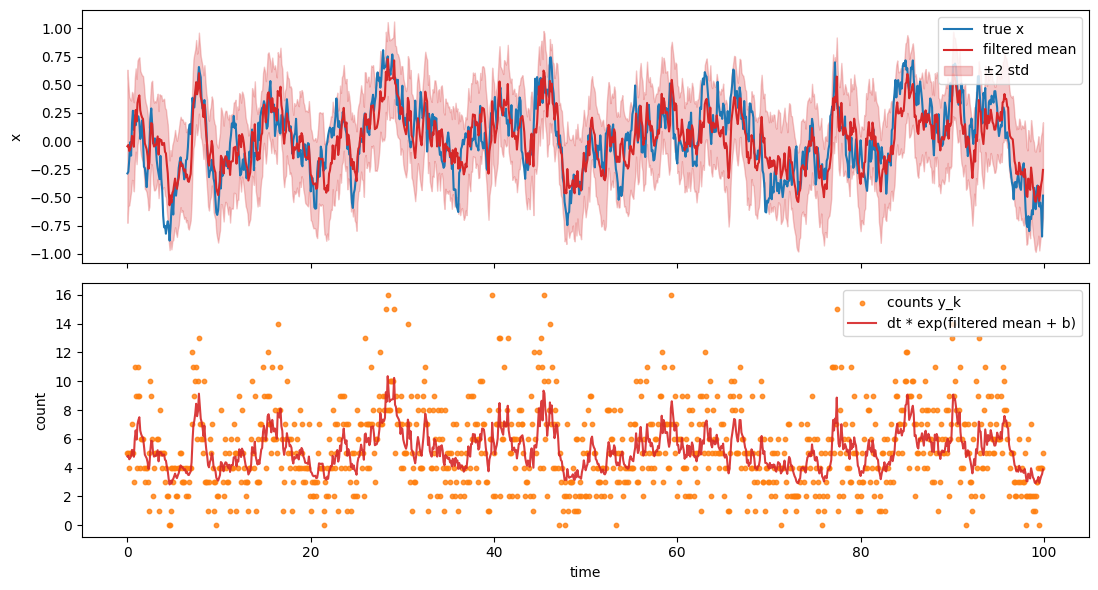

In [6]:
# Plot filtered state estimate (mean +/- 2 std) and compare against truth

t = t_emissions.squeeze()
m = filtered.filtered_means[:, 0]
s = jnp.sqrt(filtered.filtered_covariances[:, 0, 0])

fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axs[0].plot(t, states[:, 0], color="C0", label="true x")
axs[0].plot(t, m, color="C3", label="filtered mean")
axs[0].fill_between(t, m - 2 * s, m + 2 * s, color="C3", alpha=0.25, label="±2 std")
axs[0].set_ylabel("x")
axs[0].legend(loc="upper right")

pred_counts = dt * jnp.exp(m + true_bias)
axs[1].scatter(t, emissions[:, 0], s=10, color="C1", alpha=0.8, label="counts y_k")
axs[1].plot(t, pred_counts, color="C3", alpha=0.9, label="dt * exp(filtered mean + b)")
axs[1].set_ylabel("count")
axs[1].set_xlabel("time")
axs[1].legend(loc="upper right")

plt.tight_layout()


### Differentiability



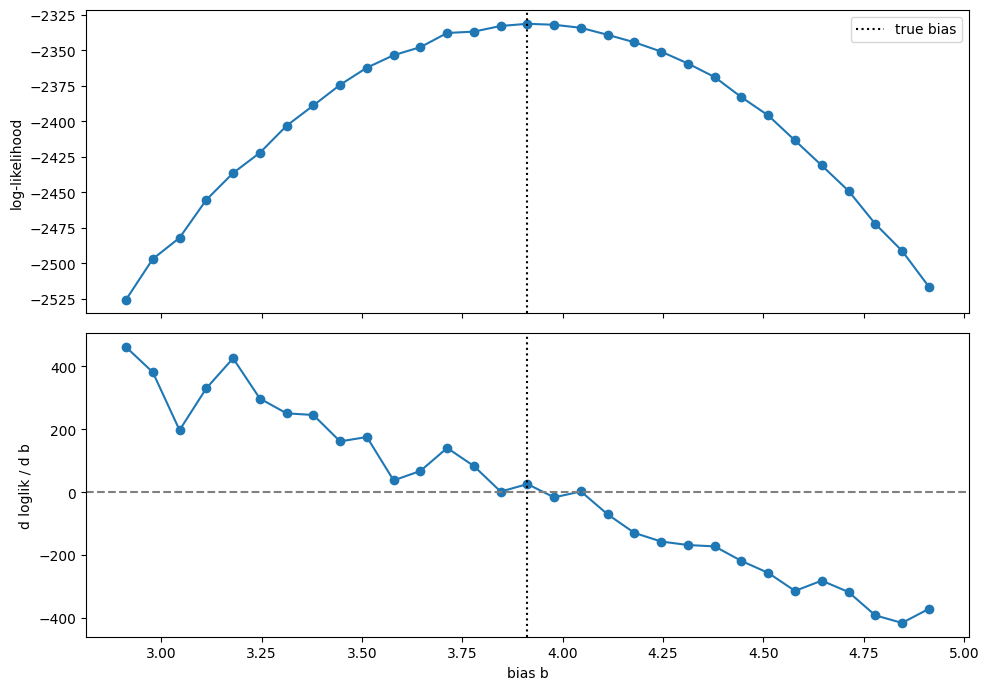

In [7]:
def dpf_loglik_for_bias(bias):
    params = cdnlssm.build_params(
        drift=lambda x: drift_ou(x, kappa=true_kappa, mu=true_mu),
        initial_mean=jnp.array([0.0]),
        initial_cov=(initial_sd**2) * jnp.eye(1),
        diffusion_coeff=true_sigma * jnp.eye(1),
        emission_distribution=PoissonEmission(dt=float(dt), bias=bias),
    )
    out = cdnlssm.filter(
        params=params,
        emissions=emissions,
        t_emissions=t_emissions,
        key=jr.PRNGKey(2),
        N_particles=500,
        warn=False,
    )
    return out.marginal_loglik


bias_grid = jnp.linspace(true_bias - 1.0, true_bias + 1.0, 31)
val_and_grad = value_and_grad(dpf_loglik_for_bias)
vals, grads = vmap(val_and_grad)(bias_grid)

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axs[0].plot(bias_grid, vals, marker="o")
axs[0].axvline(true_bias, color="k", linestyle=":", label="true bias")
axs[0].set_ylabel("log-likelihood")
axs[0].legend(loc="best")

axs[1].plot(bias_grid, grads, marker="o")
axs[1].axhline(0.0, color="gray", linestyle="--")
axs[1].axvline(true_bias, color="k", linestyle=":")
axs[1].set_xlabel("bias b")
axs[1].set_ylabel("d loglik / d b")

plt.tight_layout()

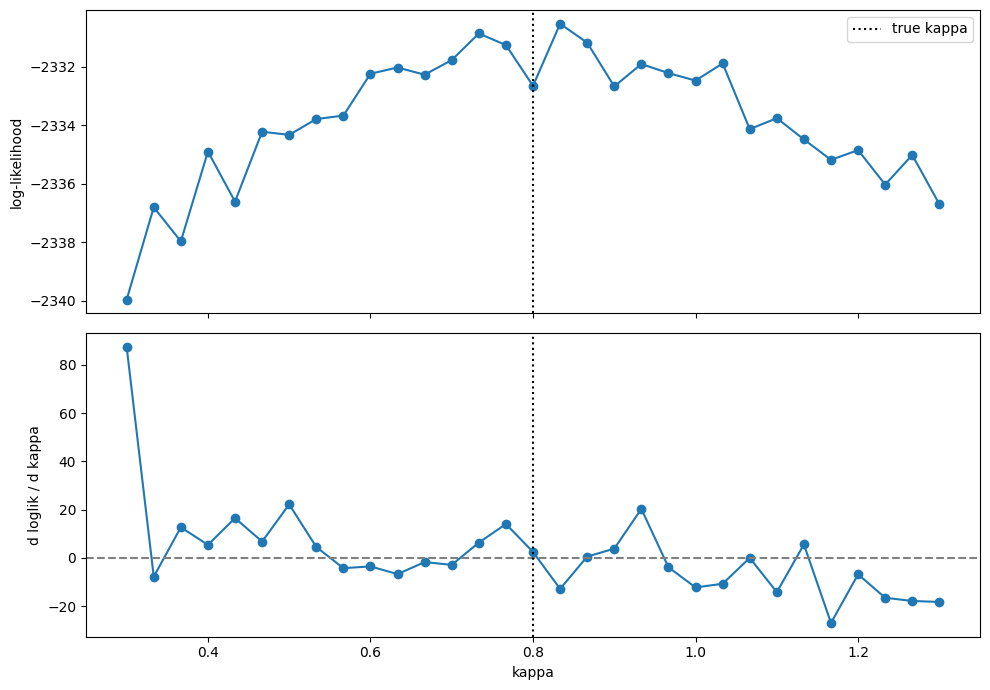

In [8]:
def dpf_loglik_for_kappa(kappa):
    params = cdnlssm.build_params(
        drift=lambda x: drift_ou(x, kappa=kappa, mu=true_mu),
        initial_mean=jnp.array([0.0]),
        initial_cov=(initial_sd**2) * jnp.eye(1),
        diffusion_coeff=true_sigma * jnp.eye(1),
        emission_distribution=PoissonEmission(dt=float(dt), bias=true_bias),
    )
    out = cdnlssm.filter(
        params=params,
        emissions=emissions,
        t_emissions=t_emissions,
        key=jr.PRNGKey(2),
        N_particles=500,
        warn=False,
    )
    return out.marginal_loglik


kappa_grid = jnp.linspace(true_kappa - 0.5, true_kappa + 0.5, 31)
val_and_grad_kappa = value_and_grad(dpf_loglik_for_kappa)
vals_kappa, grads_kappa = vmap(val_and_grad_kappa)(kappa_grid)

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axs[0].plot(kappa_grid, vals_kappa, marker="o")
axs[0].axvline(true_kappa, color="k", linestyle=":", label="true kappa")
axs[0].set_ylabel("log-likelihood")
axs[0].legend(loc="best")

axs[1].plot(kappa_grid, grads_kappa, marker="o")
axs[1].axhline(0.0, color="gray", linestyle="--")
axs[1].axvline(true_kappa, color="k", linestyle=":")
axs[1].set_xlabel("kappa")
axs[1].set_ylabel("d loglik / d kappa")

plt.tight_layout()


# Tracking with Non-Gaussian Observations

We now provide a tracking example with non-Gaussian observations, where observations consist of a bearing estimate (that lives in the circle, $S^1$) and a power estimate (that lives in $\mathbb{R}$).

Let the continuous-time latent state be planar position and velocity
$$
X_t =
\begin{bmatrix}
p_t \\ v_t
\end{bmatrix}
\in \mathbb{R}^4,
\qquad
p_t = (x_t,y_t),\; v_t = (\dot x_t,\dot y_t).
$$

### State dynamics (continuous-time SDE)

\begin{aligned}
dp_t &= v_t\,dt, \\
dv_t &= -\alpha\, v_t\,dt + \Sigma\, dW_t,
\end{aligned}
where $\alpha>0$ is a damping parameter, $\Sigma\in\mathbb{R}^{2\times 2}$ is a diffusion matrix, and $W_t$ is a 2D Brownian motion.

### Observation model (discrete-time, non-Gaussian)
At observation times $t_k = k\Delta$, a fixed sensor at location
$s=(s_x,s_y)\in\mathbb{R}^2$ measures the bearing angle *and* a noisy signal power:
$$
(Y_k, Z_k)\mid X_{t_k}\;\;\text{with}\;\;
\begin{cases}
Y_k \mid X_{t_k} \sim \mathrm{vonMises}\!\left(\mu_k,\;\kappa_y\right),\\[4pt]
Z_k \mid X_{t_k} \sim \mathcal{N}\!\left(m_k,\;\sigma_z^2\right),
\end{cases}
$$
(typically taken conditionally independent given $X_{t_k}$).

The bearing mean direction is
$$
\mu_k = \operatorname{atan2}\!\big(y_{t_k}-s_y,\; x_{t_k}-s_x\big),
$$
with concentration parameter $\kappa_y>0$.

For signal power, let the range be
$$
r_k = \big\|p_{t_k}-s\big\|_2,
$$
and use a simple log-distance path-loss model (in dB/dBm):
$$
m_k = P_0 - 10\,n\,\log_{10}\!\left(\frac{r_k}{r_0}\right),
$$
where $P_0$ is the mean received power at reference distance $r_0$, $n>0$ is the path-loss exponent, and $\sigma_z^2$ is the (measurement) variance.

In [9]:
import jax.numpy as jnp
import jax.random as jr
import tensorflow_probability.substrates.jax.distributions as tfd


class BearingEmission:
    """von Mises bearing observation + noisy signal power from a fixed sensor location."""

    def __init__(self, sensor_xy, kappa, P0, n, r0, sigma_z):
        self.sensor_xy = jnp.asarray(sensor_xy)
        self.kappa = kappa
        self.P0 = P0
        self.n = n
        self.r0 = r0
        self.sigma_z = sigma_z

    def _loc(self, x):
        dx = x[..., 0] - self.sensor_xy[0]
        dy = x[..., 1] - self.sensor_xy[1]
        return jnp.arctan2(dy, dx)

    def _range(self, x):
        dx = x[..., 0] - self.sensor_xy[0]
        dy = x[..., 1] - self.sensor_xy[1]
        return jnp.sqrt(dx * dx + dy * dy)

    def _power_mean(self, x):
        r = jnp.maximum(self._range(x), 1e-12)  # avoid log(0)
        return self.P0 - 10.0 * self.n * jnp.log10(r / self.r0)

    def log_prob(self, y, x=None, u=None, t=None):
        y_b = jnp.squeeze(y[..., 0])
        y_p = jnp.squeeze(y[..., 1])

        loc = self._loc(x)
        m = self._power_mean(x)

        lp_b = tfd.VonMises(loc=loc, concentration=self.kappa).log_prob(y_b)
        lp_p = tfd.Normal(loc=m, scale=self.sigma_z).log_prob(y_p)
        return lp_b + lp_p

    def sample(self, x=None, u=None, t=None, seed=None):
        loc = self._loc(x)
        m = self._power_mean(x)

        seed_b, seed_p = jr.split(seed, 2) 

        y_b = tfd.VonMises(loc=loc, concentration=self.kappa).sample(seed=seed_b)
        y_p = tfd.Normal(loc=m, scale=self.sigma_z).sample(seed=seed_p)
        return jnp.stack([y_b, y_p], axis=-1)


In [10]:
# Simulate bearing+power data (position+velocity state)
cdnlssm_bearing = ContDiscreteNonlinearSSM(state_dim=4, emission_dim=2)

alpha = 0.5  # velocity damping
sigma_v = 0.4  # process noise std for velocity
sensor_xy = jnp.array([7.0, 0.0])
bearing_kappa = 30.0

# signal power parameters (log-distance path-loss)
P0 = -40.0  # mean power at reference distance r0 (dB/dBm)
n = 2.0  # path-loss exponent
r0 = 1.0  # reference distance
sigma_z = 2.0  # power measurement noise std (dB)

T = 500
dt = 0.5
t_emissions = (jnp.arange(T) * dt).reshape(-1, 1)


class BearingDrift(eqx.Module):
    alpha: jnp.ndarray

    def f(self, x, u=None, t=None):
        px, py, vx, vy = x
        return jnp.array([vx, vy, -self.alpha * vx, -self.alpha * vy])


# Diffusion acts only on velocities
diffusion_coeff = jnp.diag(jnp.array([0.0, 0.0, sigma_v, sigma_v]))
diffusion_cov = jnp.eye(4)

bearing_emission = BearingEmission(
    sensor_xy=sensor_xy, kappa=bearing_kappa, P0=P0, n=n, r0=r0, sigma_z=sigma_z
)
bearing_drift = BearingDrift(alpha=jnp.array(alpha))

bearing_params = cdnlssm_bearing.build_params(
    drift=bearing_drift.f,
    initial_mean=jnp.array([0.0, 0.0, 1.0, 0.5]),
    initial_cov=jnp.diag(jnp.array([0.5, 0.5, 0.2, 0.2]) ** 2),
    diffusion_coeff=diffusion_coeff,
    diffusion_cov=diffusion_cov,
    emission_distribution=bearing_emission,
)

bearing_states, bearing_emissions = cdnlssm_bearing.sample(
    params=bearing_params,
    key=jr.PRNGKey(123),
    num_timesteps=T,
    t_emissions=t_emissions,
    transition_type="path",
)

# Shape emissions for downstream use
bearing_emissions = bearing_emissions.reshape(-1, 2)
true_bearings = jnp.arctan2(
    bearing_states[:, 1] - sensor_xy[1], bearing_states[:, 0] - sensor_xy[0]
)


Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.


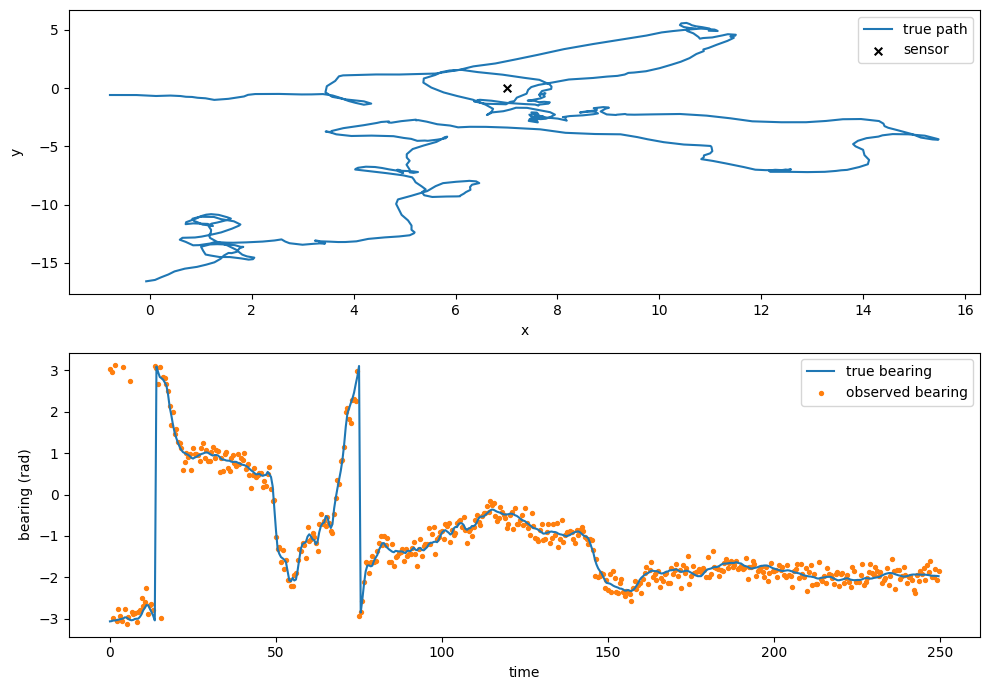

In [11]:
# Plot true trajectory and bearing observations
fig, axs = plt.subplots(2, 1, figsize=(10, 7))

axs[0].plot(bearing_states[:, 0], bearing_states[:, 1], label="true path")
axs[0].scatter(*sensor_xy, color="k", marker="x", label="sensor", s=30)
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].legend(loc="upper right")

axs[1].plot(t_emissions.squeeze(), true_bearings, label="true bearing")
axs[1].scatter(t_emissions.squeeze(), bearing_emissions[:, 0], s=8, color="C1", label="observed bearing")
axs[1].set_xlabel("time")
axs[1].set_ylabel("bearing (rad)")
axs[1].legend(loc="upper right")

plt.tight_layout()

In [12]:
# Run DPF on bearing-only data
bearing_filtered = cdnlssm_bearing.filter(
    params=bearing_params,
    emissions=bearing_emissions,
    t_emissions=t_emissions,
    key=jr.PRNGKey(321),
    N_particles=1_000,
    warn=False,
)

print("Tracking DPF marginal log-likelihood:", float(bearing_filtered.marginal_loglik))

Tracking DPF marginal log-likelihood: -1087.4046630859375


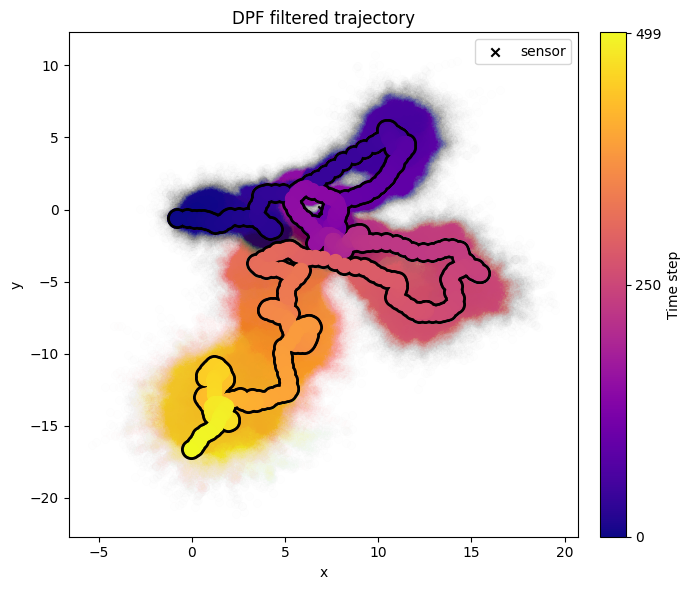

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

cmap = mpl.colormaps["plasma"]

points = []
colors = []

for t in range(T):
    ax.scatter(
        bearing_states[t, 0],
        bearing_states[t, 1],
        color="black",
        s=200,
        zorder=1
    )
    cval = t / T
    ax.scatter(
        bearing_states[t, 0],
        bearing_states[t, 1],
        color=cmap(cval),
        s=100,
        zorder=2,
    )

    # Keep track of each time and state for colorbar
    points.append([bearing_states[t, 0], bearing_states[t, 1]])
    colors.append(cval)

    ax.scatter(bearing_filtered.particles[t, :, 0], bearing_filtered.particles[t, :, 1], color=cmap(cval), alpha=0.005, zorder=1)

ax.scatter(*sensor_xy, color="k", marker="x", label="sensor")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="best")
ax.set_title("DPF filtered trajectory")

# Add colorbar for time
norm = mpl.colors.Normalize(vmin=0, vmax=T)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=0, vmax=T))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label='Time step')
cbar.set_ticks([0, T//2, T-1])
cbar.set_ticklabels([0, T//2, T-1])

plt.tight_layout()

## EnKF With Assumed Gaussian Emissions on Same Data


In [14]:
# Reuse the same latent path and bearing+power observations, but assume Gaussian emissions
cdnlgssm_gauss = ContDiscreteNonlinearGaussianSSM(state_dim=4, emission_dim=2)

sigma_y = 0.15  # Gaussian bearing noise std (radians)
sigma_z = 2.0  # Gaussian power noise std (dB)  (same meaning as before)


def bearing_power_fn(x, u=None, t=None):
    px, py, vx, vy = x
    r = jnp.sqrt((px - sensor_xy[0]) ** 2 + (py - sensor_xy[1]) ** 2)
    r = jnp.maximum(r, 1e-12)  # avoid log(0)
    bearing = jnp.arctan2(py - sensor_xy[1], px - sensor_xy[0])
    power = P0 - 10.0 * n * jnp.log10(r / r0)
    return jnp.array([bearing, power])


params_gauss = cdnlgssm_gauss.build_params(
    drift=bearing_drift.f,
    initial_mean=jnp.array([0.0, 0.0, 1.0, 0.5]),
    initial_cov=jnp.diag(jnp.array([0.5, 0.5, 0.2, 0.2]) ** 2),
    diffusion_coeff=diffusion_coeff,
    diffusion_cov=diffusion_cov,
    emission_function=bearing_power_fn,
    emission_cov=jnp.diag(jnp.array([sigma_y**2, sigma_z**2])),
)

filtered_gauss = cdnlgssm_gauss.filter(
    params=params_gauss,
    emissions=bearing_emissions,
    t_emissions=t_emissions,
    inputs=None,
    filter_type="EnKF",
    enkf_N_particles=1_000,
    warn=False,
)

print(
    "Gaussian (bearing+power) EnKF marginal log-likelihood:",
    float(filtered_gauss.marginal_loglik),
)


Gaussian (bearing+power) EnKF marginal log-likelihood: -1817.425537109375


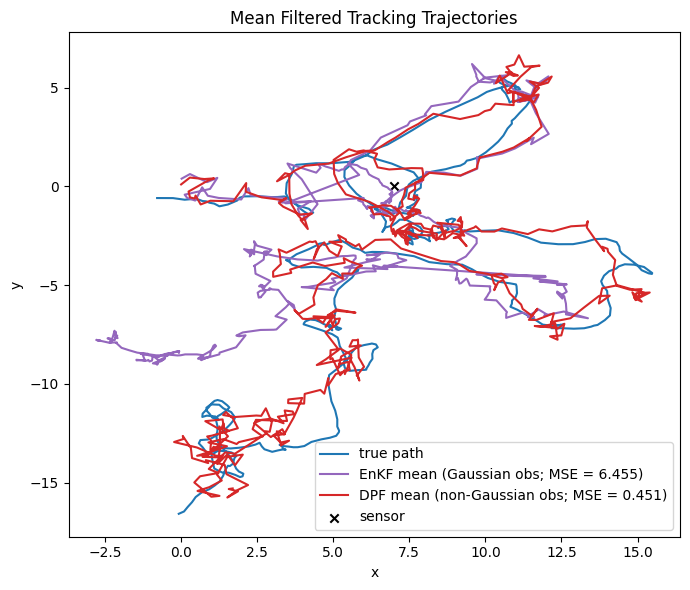

In [15]:
# Plot EnKF filtered position
pos_mean_g = filtered_gauss.filtered_means[:, :2]
pos_cov_g = filtered_gauss.filtered_covariances[:, :2, :2]
pos_std_g = jnp.sqrt(jnp.diagonal(pos_cov_g, axis1=1, axis2=2))

dpf_mse = jnp.mean((bearing_filtered.filtered_means[:, :2] - bearing_states[:, :2]) ** 2)
enkf_mse = jnp.mean((filtered_gauss.filtered_means[:, :2] - bearing_states[:, :2]) ** 2)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.plot(bearing_states[:, 0], bearing_states[:, 1], color="C0", label="true path")
ax.plot(pos_mean_g[:, 0], pos_mean_g[:, 1], color="C4", label="EnKF mean (Gaussian obs; MSE = {:.3f})".format(enkf_mse))
ax.plot(bearing_filtered.filtered_means[:, 0], bearing_filtered.filtered_means[:, 1], color="C3", label="DPF mean (non-Gaussian obs; MSE = {:.3f})".format(dpf_mse))

ax.scatter(*sensor_xy, color="k", marker="x", label="sensor")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="best")
ax.set_title("Mean Filtered Tracking Trajectories")
plt.tight_layout()